In [4]:
from level_transition import iso_gatom_level_tr_strain
from annihilation     import iso_gatom_ann_strain
from matplotlib import pyplot as plt
import numpy as np

In [5]:
# helper to format numbers as A×10^B in LaTeX
def sci_latex(x, precision=2):
    if x == 0:
        return "0"
    exponent = int(np.floor(np.log10(abs(x))))
    mantissa = x / 10**exponent
    return f"{mantissa:.{precision}f}\\times10^{{{exponent}}}"

# shared font sizes
title_fs  = 20
label_fs  = 20
tick_fs   = 18
legend_fs = 15

# Isolated Level Transition Strain
Below is the envelope for the level transition strain \
When the oscillatory term is added, it only shifts the frequency axis to the transition frequency \
The width of the strain envelope is entirely set by the transition rate


 alpha    = 0.75
 omega_tr = 3.4451407454141036e-16
 r_g(M)   = 7.4834e+12 GeV^-1
 M        = 1.1154e+51 GeV
Max N_e      ≈ 9.303e+57
Max N_g      ≈ 3.662e+58
Max h(t)     ≈ 2.148e-31
omega_tr     ≈ 3.445e-16 GeV
gamma_sre_yr ≈ 1.680e+04 1/yr
gamma_srg_yr ≈ 1.532e+04 1/yr
gamma_t_yr   ≈ 1.678e-53 1/yr
gamma_srg    ≈ 3.198e-28 1/GeV
Mu_a         ≈ 1.002e-13 GeV


/home/cherrytree/bosonSR_repo_/chris/constants.py:356: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(log_lorentzian, f_fit, ydata, p0=p0, maxfev=20000)


Fitted centre frequency f0 = 1.873602e-04 Hz
Fitted width gamma         = 2.818589e-04 Hz
Estimated FWHM ≃ 2·gamma   = 5.637178e-04 Hz
Fitted floor C             = 1.436e-41
dict_keys(['time_yr', 'h_t', 'N_e', 'N_g', 'f_pos', 'H_pos', 'L_full', 'lorentz_params', 'omega_tr_GeV', 'Mu_a'])


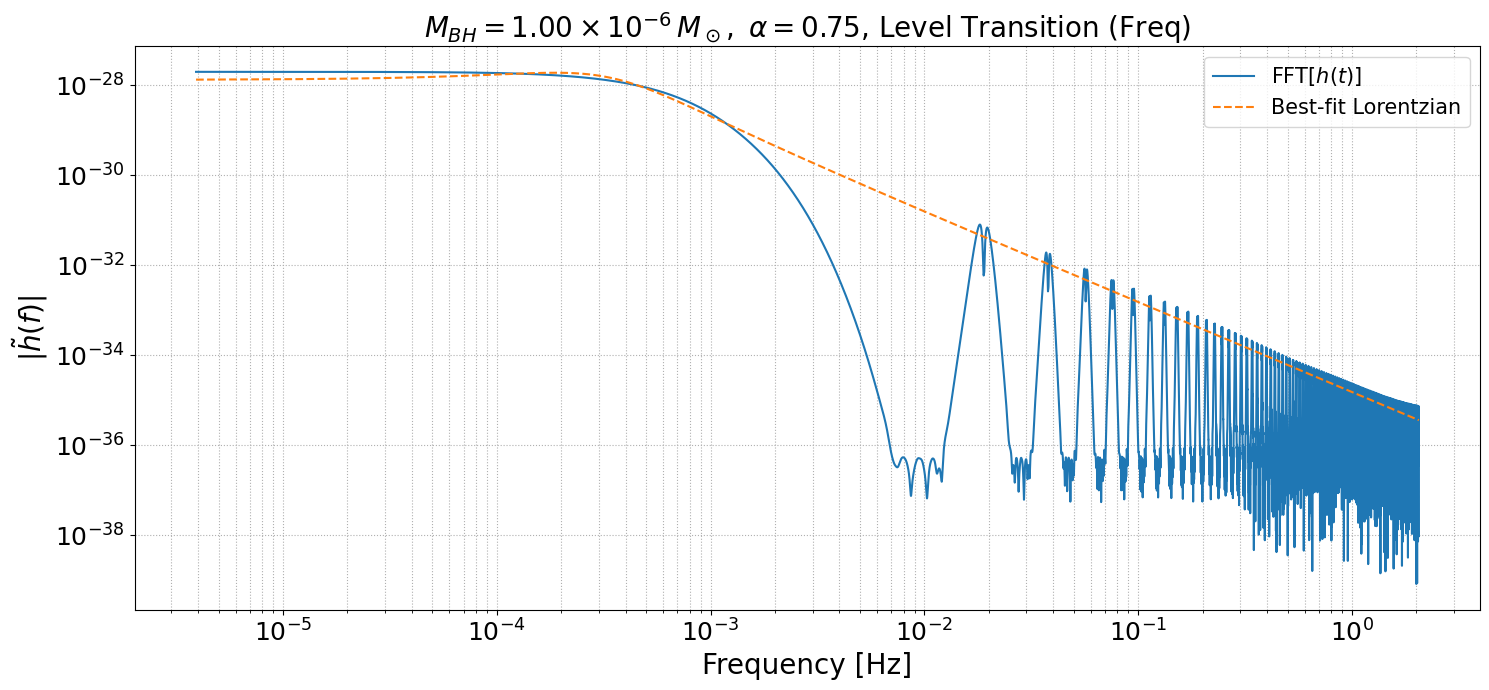

In [6]:
result = iso_gatom_level_tr_strain(
    M_solar      = 1e-6,
    a_spin       = 0.999999,
    alpha        = 0.75,
    ne           = 6,
    ng           = 5,
    distance_kpc = 1.0,
    verbose      = True,
)

print(result.keys())

# Freq axis
f = result["f_pos"]
# FFT of time-domain strain
H = result["H_pos"]
# Fitted Lorentzian
L = result["L_full"]

A_fit, f0_fit, gamma_fit, C_fit = result["lorentz_params"]
omega_tr = result["omega_tr_GeV"]
mu_a     = result["Mu_a"]
M_solar  = 1e-6

plt.figure(figsize=(15, 7))
plt.title(
    r'$M_{{BH}}={}\,M_\odot,\ \alpha=0.75$, Level Transition (Freq)'.format(
        sci_latex(M_solar)),
    fontsize=title_fs
)
plt.loglog(f, np.abs(H), label=r'FFT$[h(t)]$')
plt.loglog(f, L, '--', label='Best-fit Lorentzian')
plt.xlabel('Frequency [Hz]', fontsize=label_fs)
plt.ylabel(r'$|\tilde h(f)|$', fontsize=label_fs)
plt.tick_params(axis='both', which='both', labelsize=tick_fs)
plt.grid(True, which='both', ls=':')
plt.legend(fontsize=legend_fs)
plt.tight_layout()
plt.show()

# Associated Time Domain Strain

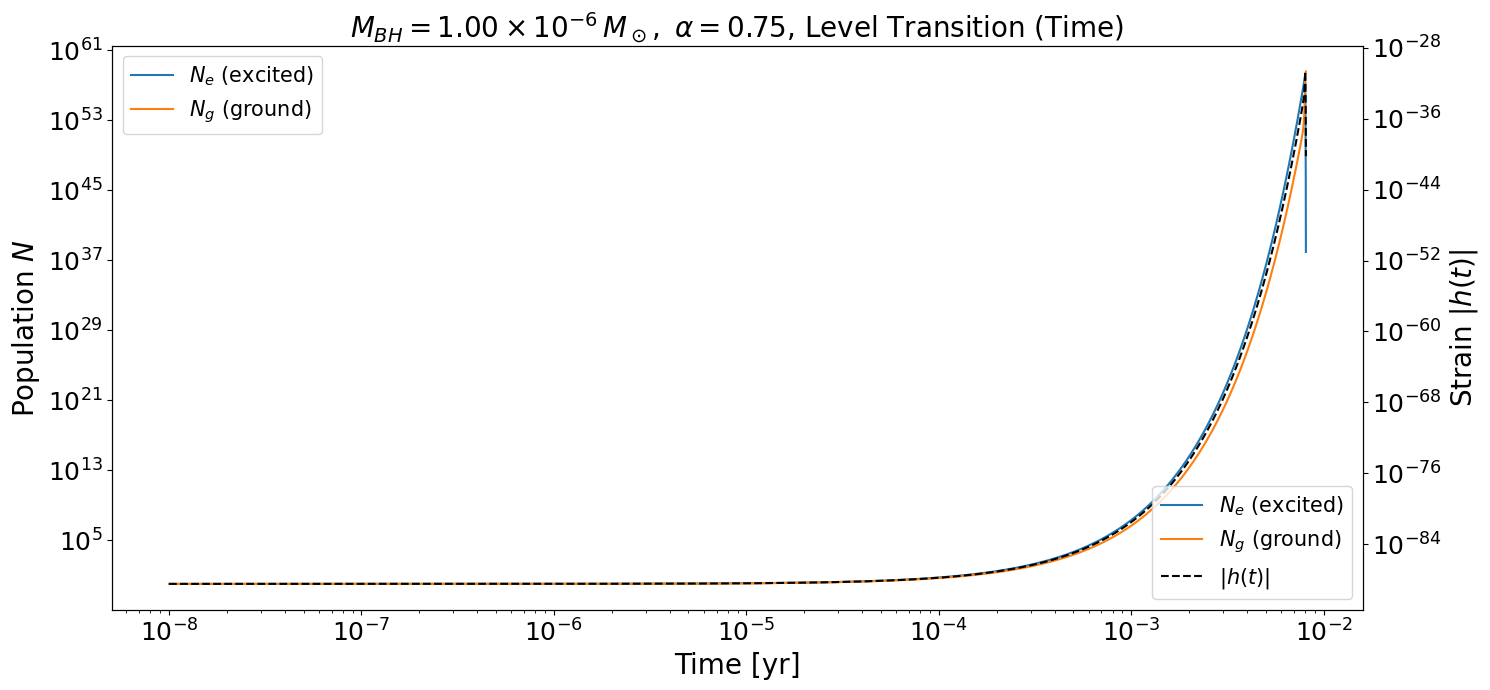

In [4]:
time_yr = result["time_yr"]
h_t     = result["h_t"]
N_e     = result["N_e"]
N_g     = result["N_g"]

fig, ax1 = plt.subplots(figsize=(15, 7))
ax1.set_title(
    r'$M_{{BH}}={}\,M_\odot,\ \alpha=0.75$, Level Transition (Time)'.format(
        sci_latex(M_solar)),
    fontsize=title_fs
)

# Populations (left y-axis)
ax1.loglog(time_yr, N_e, label=r'$N_e$ (excited)')
ax1.loglog(time_yr, N_g, label=r'$N_g$ (ground)')
ax1.set_xlabel('Time [yr]', fontsize=label_fs)
ax1.set_ylabel('Population $N$', fontsize=label_fs)
ax1.tick_params(axis='both', which='both', labelsize=tick_fs)
ax1.legend(loc='upper left', fontsize=legend_fs)

# Strain (right y-axis)
ax2 = ax1.twinx()
ax2.loglog(time_yr, np.abs(h_t), 'k--', label=r'$|h(t)|$')
ax2.set_ylabel('Strain $|h(t)|$', fontsize=label_fs)
ax2.tick_params(axis='both', which='both', labelsize=tick_fs)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=legend_fs)

fig.tight_layout()
plt.show()

# Annihilation Strain

In [5]:
# ---------------------------------------------------------
# chosen parameters
# ---------------------------------------------------------
M_solar_ann  = 3.1e-4    # BH mass [solar masses]
mua_ann      = 2e-16     # boson mass [GeV]
distance_kpc = 1.0
n_ann        = 4
iota_ann     = 0.0
phase_ann    = 0.0

f_min = 1e0
f_max = 1e12
N_f   = 50000

# ---------------------------------------------------------
# call the annihilation master function
# ---------------------------------------------------------
res_ann = iso_gatom_ann_strain(
    M_solar      = M_solar_ann,
    mua          = mua_ann,
    n            = n_ann,
    l            = None,          # default n-1
    alpha        = None,          # computed as α = G M μ
    distance_kpc = distance_kpc,
    iota         = iota_ann,
    phase        = phase_ann,
    f_min_Hz     = f_min,
    f_max_Hz     = f_max,
    n_f          = N_f,
    verbose      = True,
)

f_Hz      = res_ann["f_Hz"]
h_c       = res_ann["h_c"]
h_plus    = res_ann["h_plus"]
f_ann     = res_ann["f_line_Hz"]
alpha_ann = res_ann["alpha"]
r_kpc     = res_ann["distance_kpc"]

alpha           ≈ 4.640e-01
r_g(M)          ≈ 2.3198e+15 GeV^-1
Annihilation f_ann ≈ 9.607e+07 Hz
max |h_plus|    ≈ 8.211e-39
max h_c         ≈ 1.591e-30


<>:26: SyntaxWarning: invalid escape sequence '\o'
<>:26: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_111957/1227370021.py:26: SyntaxWarning: invalid escape sequence '\o'
  label=f'$\omega_{{ann}}$ = {f_ann/1e6:.3e} MHz',


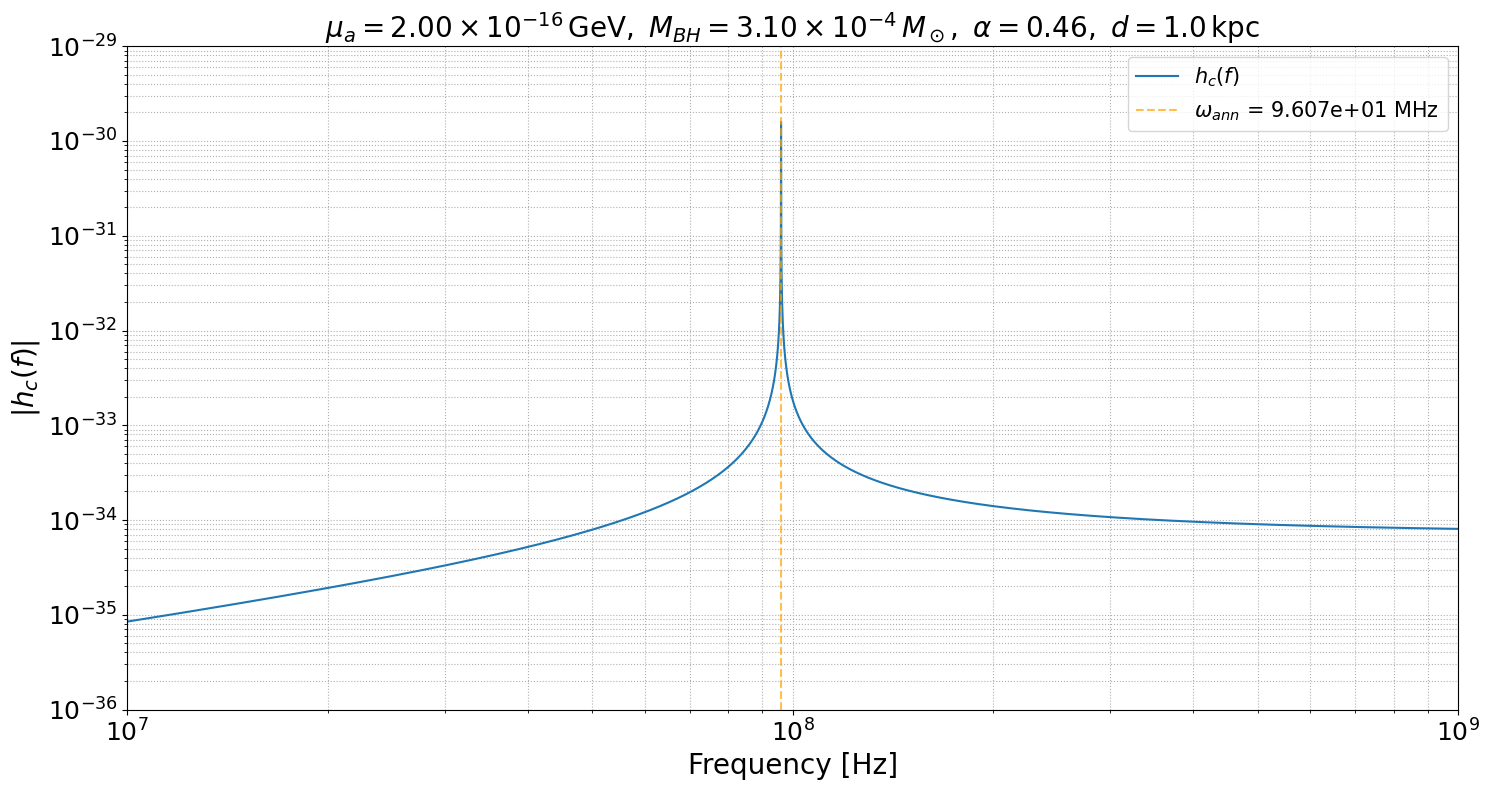

In [6]:
# ---------------------------------------------------------
# plot annihilation characteristic strain
# ---------------------------------------------------------
plt.figure(figsize=(15, 8))

plt.plot(f_Hz, np.abs(h_c), label=r'$h_c(f)$')

plt.xscale('log')
plt.yscale('log')
plt.xlim(1e7, 1e9)
plt.ylim(1e-36, 1e-29)

plt.xlabel('Frequency [Hz]', fontsize=label_fs)
plt.ylabel(r'$|h_c(f)|$', fontsize=label_fs)
plt.tick_params(axis='both', which='both', labelsize=tick_fs)

plt.title(
    r'$\mu_a = {}\,\mathrm{{GeV}},\ $'.format(sci_latex(mua_ann)) +
    r'$M_{{BH}} = {}\,M_\odot,\ $'.format(sci_latex(M_solar_ann)) +
    r'$\alpha = {:.2f},\ d = {:.1f}\,\mathrm{{kpc}}$'.format(alpha_ann, r_kpc),
    fontsize=title_fs
)

plt.vlines(
    f_ann, 1e-36, 1e-29,
    label=f'$\omega_{{ann}}$ = {f_ann/1e6:.3e} MHz',
    linestyles='--', color='orange', alpha=0.7
)

plt.grid(True, which='both', ls=':')
plt.legend(fontsize=legend_fs)
plt.tight_layout()
plt.show()

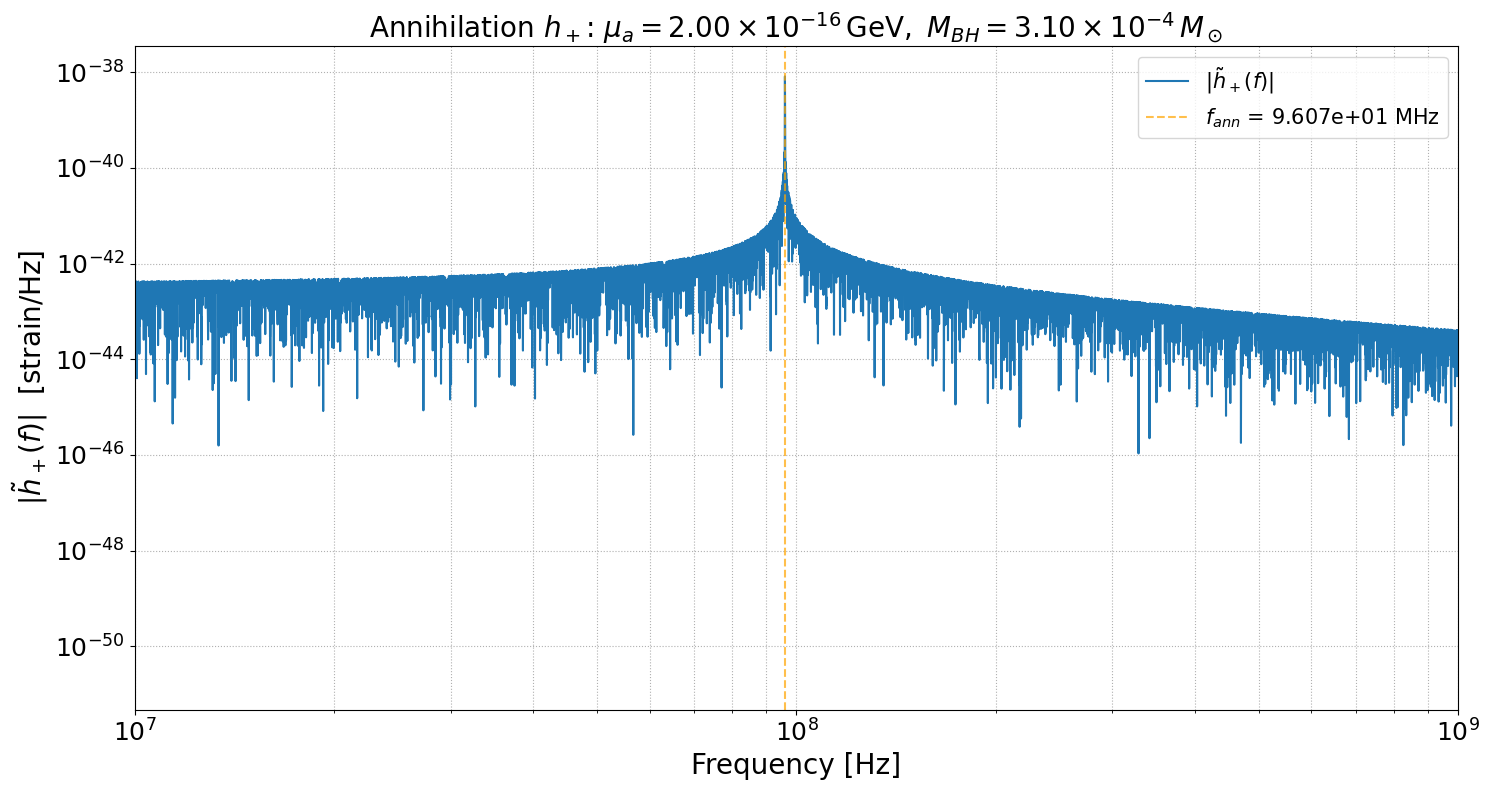

In [7]:
# ---------------------------------------------------------
# plus polarisation h̃_+(f)  [strain/Hz]
# ---------------------------------------------------------
plt.figure(figsize=(15, 8))

plt.plot(f_Hz, np.abs(h_plus), label=r'$|\tilde h_+(f)|$')

plt.xscale('log')
plt.yscale('log')
plt.xlim(1e7, 1e9)

plt.xlabel('Frequency [Hz]', fontsize=label_fs)
plt.ylabel(r'$|\tilde h_+(f)|$  [strain/Hz]', fontsize=label_fs)
plt.tick_params(axis='both', which='both', labelsize=tick_fs)

plt.title(
    r'Annihilation $h_+$: $\mu_a = {}\,\mathrm{{GeV}},\ $'.format(sci_latex(mua_ann)) +
    r'$M_{{BH}} = {}\,M_\odot$'.format(sci_latex(M_solar_ann)),
    fontsize=title_fs
)

plt.vlines(
    f_ann, plt.ylim()[0], plt.ylim()[1],
    label=f'$f_{{ann}}$ = {f_ann/1e6:.3e} MHz',
    linestyles='--', color='orange', alpha=0.7
)

plt.grid(True, which='both', ls=':')
plt.legend(fontsize=legend_fs)
plt.tight_layout()
plt.show()

# Both Strains on the Same Axis
Overlay the Lorentzian-fitted level-transition strain and the annihilation characteristic strain.
Note that the level transition is essentially a delta spike for the detectors we are considering, the duration is far too short to realisticaly detect for most masses considered

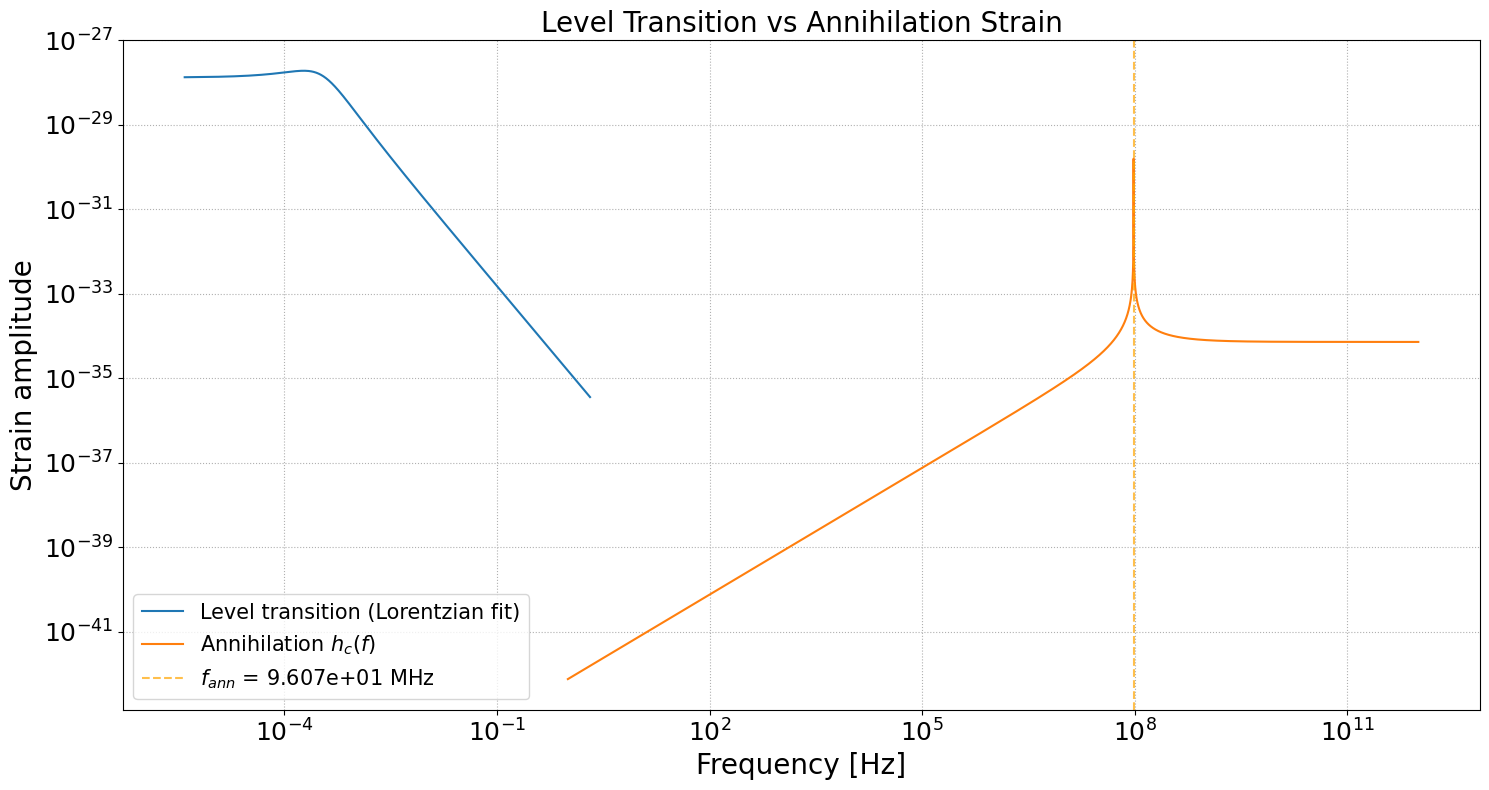

In [8]:
fig, ax = plt.subplots(figsize=(15, 8))

ax.loglog(f,     L,           label='Level transition (Lorentzian fit)')
ax.loglog(f_Hz,  np.abs(h_c), label=r'Annihilation $h_c(f)$')

ax.axvline(f_ann, color='orange', ls='--', alpha=0.7,
           label=f'$f_{{ann}}$ = {f_ann/1e6:.3e} MHz')

ax.set_xlabel('Frequency [Hz]', fontsize=label_fs)
ax.set_ylabel(r'Strain amplitude', fontsize=label_fs)
ax.tick_params(axis='both', which='both', labelsize=tick_fs)
ax.set_title('Level Transition vs Annihilation Strain', fontsize=title_fs)
ax.grid(True, which='both', ls=':')
ax.legend(fontsize=legend_fs)
fig.tight_layout()
plt.show()